# 04 · Ranh giới giữa các file: có nên nối file khi tìm stay-point?

**Câu hỏi:** Mỗi file `.plt` là một lần bật máy ghi. Khi tìm stay-point, ta nên chạy **riêng từng file**, **nối tất cả file** của một user, hay **nối có điều kiện**?

**Vấn đề của hai cách cực đoan:**
- *Nối tất cả*: bộ phát hiện chỉ yêu cầu cửa sổ dài **ít nhất** 30 phút, không có giới hạn trên. Hai file cách nhau nhiều năm nhưng tình cờ bắt đầu gần chỗ cũ sẽ thành một stay-point "nhiều năm" (ví dụ user 055).
- *Riêng từng file*: nếu người dùng tắt máy ở nhà buổi tối và bật lại ở nhà sáng hôm sau, thời gian ở nhà nằm **giữa** hai file. Không file nào chứa nó, nên stay-point qua đêm bị mất, trong khi đó chính là loại cần để tìm Home.

**Khái niệm:**
- *Cặp ranh giới*: hai file liền nhau theo thời gian của cùng một user (A rồi B).
- *Khoảng ngắt giữa file* `gap_h`: từ điểm cuối của A tới điểm đầu của B (giờ).
- *Khoảng cách bắt đầu lại* `dist_m`: từ điểm cuối của A tới điểm đầu của B (mét).
- *Bắt đầu lại gần* (`near`): `dist_m ≤ 200 m`, dùng lại bán kính stay-point.
- *Nối có điều kiện với ngưỡng T_max*: ghép B vào sau A nếu `gap_h ≤ T_max`, rồi chạy bộ phát hiện trên cả chuỗi. Điều kiện 200 m **không cần viết thêm** vì bộ phát hiện đã tự kiểm tra: nếu B bắt đầu ở xa thì không cửa sổ nào vượt qua được ranh giới.

**Dữ liệu:** output đã làm sạch `data/processed/users/` (`clean_trajectory`). Giờ địa phương là UTC+8 cố định (lệch với 2.43% điểm ở nước ngoài, xem notebook 09).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK = "04_file_boundaries"
DATA_DIR = Path("../data/raw")
OUT_DIR = Path("outputs") / NOTEBOOK
FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR = (OUT_DIR / d for d in ("figures", "tables", "cache", "maps"))
for d in (FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(Path("../src").resolve()))
import folium

from gps.data.processing import _haversine_vectorized
from gps.features.stay_point import DistanceMode, StayPointDetector

USERS_DIR = Path("../data/processed/users")
RADIUS_M = 200          # stay-point radius
MIN_STAY_MIN = 30       # stay-point time threshold
LOCAL = pd.Timedelta(hours=8)


def load_labels(user_dir: Path) -> pd.DataFrame | None:
    """labels.txt of one user (EDA only - production does not use transport labels)."""
    path = user_dir / "labels.txt"
    if not path.exists():
        return None
    df = pd.read_csv(path, sep="\t", skiprows=1, header=None, names=["start", "end", "mode"])
    df["start"] = pd.to_datetime(df["start"], format="%Y/%m/%d %H:%M:%S", errors="coerce")
    df["end"] = pd.to_datetime(df["end"], format="%Y/%m/%d %H:%M:%S", errors="coerce")
    return df.dropna(subset=["start", "end"])


def covers_local_hour(t0: pd.Series, t1: pd.Series, hour: int = 3) -> pd.Series:
    """True if the GMT interval [t0, t1] contains a local (UTC+8) clock time `hour`:00."""
    first = (t0 + LOCAL).dt.normalize() + pd.Timedelta(hours=hour)
    first = first.where(first >= t0 + LOCAL, first + pd.Timedelta(days=1))
    return first <= t1 + LOCAL

## 1. Bảng file và cặp ranh giới
Mỗi file lấy điểm đầu và điểm cuối (sau làm sạch). Mỗi cặp file liền nhau của cùng một user cho một dòng trong `pairs`.

In [2]:
FILES_PATH = CACHE_DIR / "files.parquet"
if FILES_PATH.exists():
    files = pd.read_parquet(FILES_PATH)
else:
    parts = []
    for path in sorted(USERS_DIR.glob("user_*.parquet")):
        df = pd.read_parquet(path, columns=["user_id", "source_file", "datetime", "lat", "lon"])
        g = df.sort_values("datetime").groupby("source_file")
        parts.append(pd.DataFrame({
            "user_id": g["user_id"].first(), "n_points": g.size(),
            "start": g["datetime"].first(), "end": g["datetime"].last(),
            "lat_start": g["lat"].first(), "lon_start": g["lon"].first(),
            "lat_end": g["lat"].last(), "lon_end": g["lon"].last()}).reset_index())
    files = pd.concat(parts, ignore_index=True).sort_values(["user_id", "start"], ignore_index=True)
    files.to_parquet(FILES_PATH)

nxt = files.groupby("user_id").shift(-1)
pairs = pd.DataFrame({
    "user_id": files["user_id"], "file_a": files["source_file"], "file_b": nxt["source_file"],
    "end_a": files["end"], "start_b": nxt["start"], "lat_end_a": files["lat_end"], "lon_end_a": files["lon_end"],
    "gap_h": (nxt["start"] - files["end"]).dt.total_seconds() / 3600,
    "dist_m": _haversine_vectorized(files["lat_end"].to_numpy(), files["lon_end"].to_numpy(),
                                    nxt["lat_start"].to_numpy(), nxt["lon_start"].to_numpy()),
}).dropna(subset=["file_b"]).reset_index(drop=True)
pairs["near"] = pairs["dist_m"] <= RADIUS_M
pairs["end_hour_local"] = (pairs["end_a"] + LOCAL).dt.hour
pairs["resume_hour_local"] = (pairs["start_b"] + LOCAL).dt.hour
pairs["covers_3am_local"] = covers_local_hour(pairs["end_a"], pairs["start_b"])

print(f"Files: {len(files):,} | users: {files['user_id'].nunique()} | boundary pairs: {len(pairs):,}")
print(f"Overlapping pairs (gap < 0): {(pairs['gap_h'] < 0).sum()}")
print(f"Resume within {RADIUS_M} m: {pairs['near'].mean():.1%}")

Files: 18,670 | users: 182 | boundary pairs: 18,488
Overlapping pairs (gap < 0): 0
Resume within 200 m: 36.6%


## 2. Phân bố khoảng ngắt giữa file
`share_of_pairs` là tỉ lệ số cặp rơi vào mỗi khoảng; `resume_within_200m` là tỉ lệ cặp mà B bắt đầu trong vòng 200 m so với điểm cuối của A.

In [3]:
BAND_EDGES = [0, 1 / 3, 1, 3, 6, 12, 18, 24, 72, 24 * 30, np.inf]
BAND_LABELS = ["<=20min", "20min-1h", "1-3h", "3-6h", "6-12h", "12-18h", "18-24h", "1-3d", "3-30d", ">30d"]
pairs["band"] = pd.cut(pairs["gap_h"], BAND_EDGES, labels=BAND_LABELS, include_lowest=True)
bands = pairs.groupby("band", observed=False).agg(
    n_pairs=("gap_h", "size"), resume_within_200m=("near", "mean"), median_dist_m=("dist_m", "median"))
bands.insert(1, "share_of_pairs", bands["n_pairs"] / bands["n_pairs"].sum())
bands.to_csv(TABLE_DIR / "gap_bands_between_files.csv")
bands.round(3)

,n_pairs,share_of_pairs,resume_within_200m,median_dist_m
band,,,,
<=20min,1414,0.076,0.494,207.044
20min-1h,853,0.046,0.536,164.251
1-3h,1288,0.070,0.446,243.414
3-6h,808,0.044,0.343,379.252
6-12h,5924,0.320,0.430,261.276
12-18h,4075,0.220,0.339,356.406
18-24h,1390,0.075,0.204,1063.089
1-3d,1829,0.099,0.208,945.308
3-30d,805,0.044,0.179,1693.297


## 3. Tín hiệu "ở yên chỗ cũ" tắt ở đâu?

Bắt đầu lại gần chỗ cũ có thể do hai nguyên nhân:
1. **Ở yên** suốt khoảng ngắt (điều ta muốn nối).
2. **Thói quen**: người dùng hay bật máy ở vài chỗ quen (nhà, cơ quan), nên dù đã đi đâu đó, lần bật sau vẫn có thể trùng chỗ cũ.

Để tách hai nguyên nhân, dùng hai mốc so sánh:
- **Mốc ngẫu nhiên** (`baseline_random_file`): so điểm cuối của A với điểm đầu của một file *ngẫu nhiên* của cùng user, cách A hơn 30 ngày. Đây là mức "gần" chỉ nhờ thói quen, không có liên tục nào.
- **Mức nền của khoảng ngắt dài** (`plateau`): tỉ lệ `near` của mọi cặp có khoảng ngắt > 24 h. Qua hơn một ngày thì gần như chắc chắn người dùng đã đi đâu đó, nên phần "gần" còn lại là do thói quen.

**Quy tắc chọn T_max:** T_max là mốc giờ đầu tiên mà khoảng tin cậy 95% của tỉ lệ `near` **chạm** khoảng tin cậy 95% của mức nền. Từ đó trở đi, việc bắt đầu lại gần chỗ cũ không còn khác thói quen, nên không còn bằng chứng người dùng đã ở yên.

Random-file baseline: 9.8%
Plateau (gap > 24 h): 19.7% +- 1.5% (n = 2,736)
First gap hour touching the plateau -> T_max = 18 h


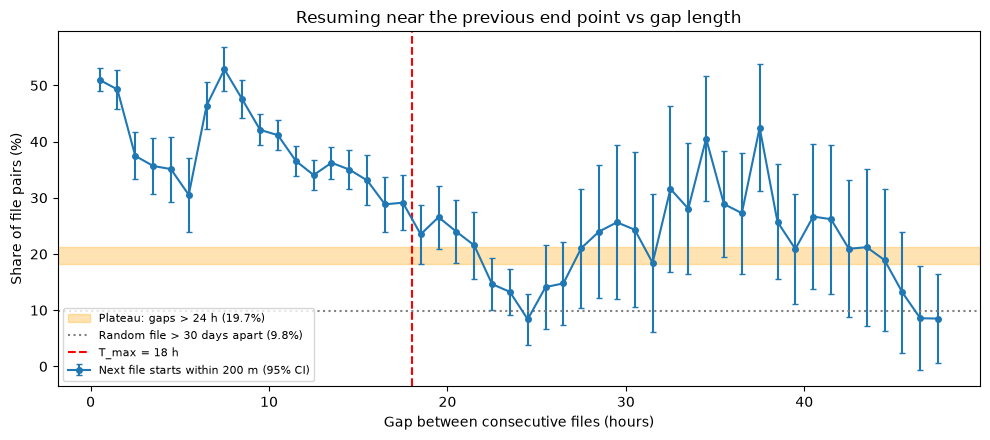

,n_pairs,resume_within_200m,ci95,touches_plateau
gap_hour,,,,
0,2267,0.510,0.021,False
1,773,0.493,0.035,False
2,515,0.375,0.042,False
3,356,0.357,0.050,False
4,262,0.351,0.058,False
5,190,0.305,0.065,False
6,558,0.464,0.041,False
7,630,0.529,0.039,False
8,848,0.475,0.034,False


In [4]:
rng = np.random.default_rng(0)
base = np.full(len(pairs), np.nan)
for uid, idx in pairs.groupby("user_id").indices.items():
    f = files[files["user_id"] == uid]
    starts = f["start"].to_numpy()
    for k in idx:
        far = np.flatnonzero(np.abs((starts - pairs.at[k, "end_a"].to_datetime64()) / np.timedelta64(1, "D")) > 30)
        if len(far):
            c = f.iloc[rng.choice(far)]
            base[k] = _haversine_vectorized(pairs.at[k, "lat_end_a"], pairs.at[k, "lon_end_a"],
                                            c["lat_start"], c["lon_start"])
pairs["baseline_near"] = np.where(np.isnan(base), np.nan, base <= RADIUS_M)

long_gap = pairs.loc[pairs["gap_h"] > 24, "near"]
plateau = long_gap.mean()
plateau_ci = 1.96 * np.sqrt(plateau * (1 - plateau) / len(long_gap))
baseline_random = pairs["baseline_near"].mean()

hourly = pairs[pairs["gap_h"] < 48].assign(gap_hour=lambda d: np.floor(d["gap_h"]).astype(int)).groupby("gap_hour").agg(
    n_pairs=("near", "size"), resume_within_200m=("near", "mean"))
hourly["ci95"] = 1.96 * np.sqrt(hourly["resume_within_200m"] * (1 - hourly["resume_within_200m"]) / hourly["n_pairs"])
hourly["touches_plateau"] = hourly["resume_within_200m"] - hourly["ci95"] <= plateau + plateau_ci
T_MAX_H = int(hourly.index[hourly["touches_plateau"]].min())
hourly.to_csv(TABLE_DIR / "resume_rate_by_gap_hour.csv")

print(f"Random-file baseline: {baseline_random:.1%}")
print(f"Plateau (gap > 24 h): {plateau:.1%} +- {plateau_ci:.1%} (n = {len(long_gap):,})")
print(f"First gap hour touching the plateau -> T_max = {T_MAX_H} h")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(hourly.index + 0.5, hourly["resume_within_200m"] * 100, yerr=hourly["ci95"] * 100,
            fmt="o-", ms=4, capsize=2, label="Next file starts within 200 m (95% CI)")
ax.axhspan((plateau - plateau_ci) * 100, (plateau + plateau_ci) * 100, color="orange", alpha=0.3,
           label=f"Plateau: gaps > 24 h ({plateau:.1%})")
ax.axhline(baseline_random * 100, color="gray", ls=":", label=f"Random file > 30 days apart ({baseline_random:.1%})")
ax.axvline(T_MAX_H, color="red", ls="--", label=f"T_max = {T_MAX_H} h")
ax.set_xlabel("Gap between consecutive files (hours)")
ax.set_ylabel("Share of file pairs (%)")
ax.set_title("Resuming near the previous end point vs gap length")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_resume_rate_by_gap_hour.png", dpi=150)
plt.show()
hourly.round(3)

## 4. Giờ tắt máy và giờ bật lại
Xét các cặp `near` có khoảng ngắt từ 20 phút tới T_max. Nếu phần lớn là tắt máy buổi tối và bật lại buổi sáng thì khoảng ngắt chủ yếu là **đêm ở một chỗ**, phù hợp với việc nối.

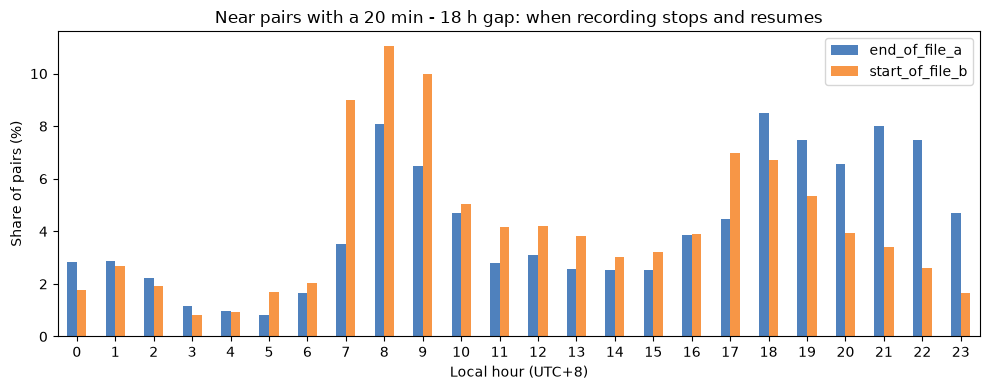

Near pairs with a 20 min - 18 h gap: 5,237, of which span 03:00 local: 46.0%, users: 141


In [5]:
bridge = pairs[pairs["near"] & (pairs["gap_h"] > 1 / 3) & (pairs["gap_h"] <= T_MAX_H)]
hours = pd.DataFrame({
    "end_of_file_a": bridge["end_hour_local"].value_counts(normalize=True),
    "start_of_file_b": bridge["resume_hour_local"].value_counts(normalize=True),
}).reindex(range(24), fill_value=0) * 100
hours.index.name = "hour_local"
hours.to_csv(TABLE_DIR / "bridge_hours_local.csv")

ax = hours.plot.bar(figsize=(10, 4), rot=0, color=["#4f81bd", "#f79646"])
ax.set_xlabel("Local hour (UTC+8)")
ax.set_ylabel("Share of pairs (%)")
ax.set_title(f"Near pairs with a 20 min - {T_MAX_H} h gap: when recording stops and resumes")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_bridge_hours_local.png", dpi=150)
plt.show()
print(f"Near pairs with a 20 min - {T_MAX_H} h gap: {len(bridge):,}, "
      f"of which span 03:00 local: {bridge['covers_3am_local'].mean():.1%}, users: {bridge['user_id'].nunique()}")

## 5. Nhãn `labels.txt` có kiểm chứng được không?

Ý tưởng giống notebook 06: nếu có chuyến đi được gắn nhãn nằm **trọn** trong khoảng ngắt (`trip_inside_gap`), người dùng đã di chuyển trong lúc máy tắt. Chỉ xét các cặp nằm trong thời kỳ user có gắn nhãn.

**Đối chứng dương:** ở các cặp *không* `near` (B bắt đầu xa hơn 200 m), người dùng **chắc chắn** đã di chuyển. Nếu nhãn nhạy, `trip_inside_gap` ở nhóm này phải cao, và nhóm `near` phải thấp hơn rõ.

In [6]:
rows = []
for uid, g in pairs.groupby("user_id"):
    lab = load_labels(DATA_DIR / uid)
    if lab is None:
        continue
    ls, le = lab["start"].to_numpy(), lab["end"].to_numpy()
    for t0, t1, near, band in zip(g["end_a"].to_numpy(), g["start_b"].to_numpy(), g["near"], g["band"], strict=True):
        if t1 < ls.min() or t0 > le.max():
            continue  # outside this user's labelling period
        rows.append({"band": band, "near": near, "trip_inside_gap": bool(((ls >= t0) & (le <= t1)).any())})
lab_df = pd.DataFrame(rows)
label_check = lab_df.pivot_table(index="band", columns="near", values="trip_inside_gap",
                                 aggfunc=["mean", "size"], observed=False).reindex(BAND_LABELS)
label_check.columns = [f"{'trip_inside_gap_pct' if a == 'mean' else 'n_pairs'}_{'near' if n else 'far'}"
                       for a, n in label_check.columns]
label_check[[c for c in label_check if c.startswith("trip")]] *= 100
label_check.to_csv(TABLE_DIR / "label_check_by_gap.csv")
print(f"Pairs inside a labelling period: {len(lab_df):,}")
label_check.round(1)

Pairs inside a labelling period: 6,928


,trip_inside_gap_pct_far,trip_inside_gap_pct_near,n_pairs_far,n_pairs_near
band,,,,
<=20min,0.0,0.0,259,298
20min-1h,2.8,0.0,109,96
1-3h,2.3,1.3,171,152
3-6h,3.3,0.0,151,71
6-12h,6.3,6.6,1358,923
12-18h,9.5,5.4,1056,630
18-24h,10.4,7.6,425,118
1-3d,13.9,12.2,596,180
3-30d,25.6,27.6,234,58


## 6. Quét T_max trên các cặp ranh giới
Chưa chạy bộ phát hiện, chỉ đếm các cặp `near` sẽ được nối với mỗi T_max: tổng số cặp, số cặp kéo qua 3 giờ sáng (đêm), số user có ít nhất một đêm được nối, và tổng số giờ không quan sát được mà việc nối thêm vào.

In [7]:
rows = []
for T in [1 / 3, 1, 3, 6, 12, T_MAX_H, 24, 48, 168, np.inf]:
    b = pairs[pairs["near"] & (pairs["gap_h"] <= T)]
    night = b[b["covers_3am_local"]]
    rows.append({"t_max_h": round(T, 2), "bridged_near_pairs": len(b), "overnight_pairs": len(night),
                 "users_with_overnight_pair": night["user_id"].nunique(), "bridged_hours": b["gap_h"].sum(),
                 "median_bridged_gap_h": b["gap_h"].median()})
sweep = pd.DataFrame(rows).drop_duplicates("t_max_h")
sweep.to_csv(TABLE_DIR / "t_max_sweep.csv", index=False)
sweep.round(1)

,t_max_h,bridged_near_pairs,overnight_pairs,users_with_overnight_pair,bridged_hours,median_bridged_gap_h
0,0.3,699,0,0,54.1,0.0
1,1.0,1156,0,0,347.7,0.2
2,3.0,1730,2,2,1369.9,0.5
3,6.0,2007,8,6,2544.7,0.8
4,12.0,4554,1316,99,26428.3,7.0
5,18.0,5936,2407,121,45873.5,8.9
6,24.0,6220,2677,125,51721.1,9.2
7,48.0,6530,2987,137,62580.1,9.5
8,168.0,6693,3150,144,76604.7,9.7
9,inf,6760,3217,147,158190.7,9.7


## 7. Chạy bộ phát hiện thật: theo file và nối với T_max

- **per_file**: như code hiện tại, `detect()` riêng từng file.
- **chained**: ghép các file liền nhau có `gap_h ≤ T_max` thành chuỗi, rồi `detect()` trên từng chuỗi. Chuỗi chỉ có một file cho kết quả giống hệt per_file nên được dùng lại.

`n_files` là số file mà một stay-point trải qua. `n_files ≥ 2` nghĩa là stay-point **vượt ranh giới file**, loại mà cách chạy theo file không thể tìm thấy.

Chạy lần đầu mất khoảng 1 giờ (bộ phát hiện chạy 2 lần trên 24 triệu điểm), kết quả được cache.

In [8]:
STAYS_PATH = CACHE_DIR / f"staypoints_per_file_vs_chained_{T_MAX_H}h.parquet"
# max_gap_hours=None: notebook này tự chia theo file / chuỗi file, vì chính nó là bằng chứng cho mốc 18 h.
detector = StayPointDetector(time_threshold_minutes=MIN_STAY_MIN, distance_threshold_meters=RADIUS_M,
                             distance_mode=DistanceMode.CENTROID, max_gap_hours=None)


def detect_rows(traj: pd.DataFrame, file_bounds: pd.DataFrame) -> list[dict]:
    out = []
    for sp in detector.detect(traj):
        arr, dep = pd.Timestamp(sp.arrival_time), pd.Timestamp(sp.departure_time)
        n_files = int(((file_bounds["start"] <= dep) & (file_bounds["end"] >= arr)).sum())
        out.append({"lat": sp.lat, "lon": sp.lon, "arrival": arr, "departure": dep,
                    "duration_min": sp.duration_minutes, "observed_min": sp.observed_minutes,
                    "n_points": sp.num_points, "n_files": n_files})
    return out


if STAYS_PATH.exists():
    stays = pd.read_parquet(STAYS_PATH)
else:
    rows = []
    user_files = sorted(USERS_DIR.glob("user_*.parquet"))
    for k, path in enumerate(user_files, start=1):
        uid = path.stem.split("_")[1]
        print(f"\r[{k}/{len(user_files)}] user {uid}", end="", flush=True)
        df = pd.read_parquet(path, columns=["source_file", "datetime", "lat", "lon", "altitude_m"])
        by_file = {name: g.sort_values("datetime") for name, g in df.groupby("source_file")}
        f = files[files["user_id"] == uid].sort_values("start").reset_index(drop=True)
        f["chain"] = (((f["start"] - f["end"].shift()).dt.total_seconds() / 3600) > T_MAX_H).cumsum()
        per_file = {}
        for name in f["source_file"]:
            per_file[name] = detect_rows(by_file[name], f[f["source_file"] == name])
            rows += [{"method": "per_file", "user_id": uid, "chain_start_file": name, **r} for r in per_file[name]]
        for _, c in f.groupby("chain"):
            if len(c) == 1:
                found = per_file[c["source_file"].iloc[0]]
            else:
                found = detect_rows(pd.concat([by_file[n] for n in c["source_file"]]), c)
            rows += [{"method": "chained", "user_id": uid, "chain_start_file": c["source_file"].iloc[0], **r}
                     for r in found]
    print()
    stays = pd.DataFrame(rows)
    stays.to_parquet(STAYS_PATH)

stays["night"] = covers_local_hour(stays["arrival"], stays["departure"])
print(stays.groupby("method").size().to_string())

method
chained     18598
per_file    12856


In [9]:
all_users = files["user_id"].nunique()
compare = stays.groupby("method").apply(lambda s: pd.Series({
    "stay_points": len(s),
    "stays_spanning_files": int((s["n_files"] >= 2).sum()),
    "dwell_hours": s["duration_min"].sum() / 60,
    "observed_share": s["observed_min"].sum() / s["duration_min"].sum(),
    "night_stays": int(s["night"].sum()),
    "users_with_night_stay": s.loc[s["night"], "user_id"].nunique(),
    "users_without_night_stay": all_users - s.loc[s["night"], "user_id"].nunique(),
    "stays_over_24h": int((s["duration_min"] > 24 * 60).sum()),
    "max_duration_h": s["duration_min"].max() / 60,
}), include_groups=False).T
compare.to_csv(TABLE_DIR / "staypoint_comparison.csv")

spanning = stays[(stays["method"] == "chained") & (stays["n_files"] >= 2)]
print(f"Stay-points spanning files: {len(spanning):,}, users: {spanning['user_id'].nunique()}, "
      f"night: {spanning['night'].mean():.1%}")
print("Duration of spanning stays (h):", (spanning["duration_min"] / 60).describe(percentiles=[.5, .9, .99]).round(1).to_dict())
compare.round(3)

Stay-points spanning files: 6,193, users: 144, night: 47.7%
Duration of spanning stays (h): {'count': 6193.0, 'mean': 9.3, 'std': 4.8, 'min': 0.5, '50%': 10.1, '90%': 14.6, '99%': 18.0, 'max': 43.8}


method,chained,per_file
stay_points,18598.000,12856.000
stays_spanning_files,6193.000,0.000
dwell_hours,79438.192,22812.916
observed_share,0.111,0.348
night_stays,3340.000,395.000
users_with_night_stay,141.000,86.000
users_without_night_stay,41.000,96.000
stays_over_24h,14.000,4.000
max_duration_h,43.782,30.668


## 8. Các đêm được khôi phục có đúng là chỗ ngủ không?

GeoLife không có nhãn Home, nên không kiểm chứng trực tiếp được. Rủi ro cần kiểm: người dùng tắt máy ở **cơ quan** lúc 18h, về nhà mà không ghi, sáng hôm sau bật lại ở cơ quan. Cách nối sẽ tạo ra một "đêm ở cơ quan" giả. Hai kiểm chứng gián tiếp:

- **(a) So với các đêm quan sát được.** Stay-point chạy theo file mà kéo qua 3 giờ sáng là những đêm máy **ghi liên tục**, không phải suy ra. Với mỗi stay-point, đo khoảng cách tới đêm quan sát được gần nhất của cùng user. Nếu đêm được khôi phục là chỗ ngủ thật, chúng phải trùng chỗ với các đêm quan sát được nhiều hơn hẳn các stay-point ban ngày. Chỉ xét user có đêm quan sát được. Tập mốc này nhỏ, nên tỉ lệ là **cận dưới**.
- **(b) Độ tập trung.** Người ta ngủ ở một hai chỗ, nhưng ban ngày đi nhiều nơi. Với mỗi user (≥ 5 stay-point mỗi loại), `share_in_top_place` là tỉ lệ stay-point nằm trong vòng 200 m quanh chỗ dày nhất.

In [10]:
night_ref = stays[(stays["method"] == "per_file") & stays["night"]]
kinds = {
    "spanning_night": spanning[spanning["night"]],
    "spanning_day": spanning[~spanning["night"]],
    "per_file_day": stays[(stays["method"] == "per_file") & ~stays["night"]],
}
rows = []
for uid, ref in night_ref.groupby("user_id"):
    for kind, grp in kinds.items():
        g = grp[grp["user_id"] == uid]
        for lat, lon in zip(g["lat"], g["lon"], strict=True):
            d = _haversine_vectorized(np.full(len(ref), lat), np.full(len(ref), lon), ref["lat"].to_numpy(), ref["lon"].to_numpy())
            rows.append({"kind": kind, "user_id": uid, "dist_to_observed_night_m": d.min()})
near_night = pd.DataFrame(rows).groupby("kind").agg(
    stay_points=("user_id", "size"), users=("user_id", "nunique"),
    within_200m=("dist_to_observed_night_m", lambda x: (x <= RADIUS_M).mean()),
    median_dist_m=("dist_to_observed_night_m", "median"))


def share_in_top_place(g: pd.DataFrame) -> float:
    la, lo = g["lat"].to_numpy(), g["lon"].to_numpy()
    return max((_haversine_vectorized(np.full(len(g), a), np.full(len(g), b), la, lo) <= RADIUS_M).sum()
               for a, b in zip(la, lo, strict=True)) / len(g)


rows = {}
for kind, grp in kinds.items():
    share = grp.groupby("user_id").filter(lambda g: len(g) >= 5).groupby("user_id")[["lat", "lon"]].apply(share_in_top_place)
    rows[kind] = {"users_5plus": len(share), "median_share_in_top_place": share.median(),
                  "p25_share_in_top_place": share.quantile(0.25)}
concentration = pd.DataFrame(rows).T
validation = near_night.join(concentration)
validation.to_csv(TABLE_DIR / "recovered_night_validation.csv")
print(f"Users with observed (per-file) night stays: {night_ref['user_id'].nunique()}")
print("\nChained stay-points longer than 24 h:")
print((stays.loc[(stays["method"] == "chained") & (stays["duration_min"] > 24 * 60), ["user_id", "n_files", "duration_min", "observed_min"]]
       .assign(duration_h=lambda d: d["duration_min"] / 60, observed_h=lambda d: d["observed_min"] / 60)
       .drop(columns=["duration_min", "observed_min"]).round(1).to_string(index=False)))
validation.round(3)

Users with observed (per-file) night stays: 86

Chained stay-points longer than 24 h:
user_id  n_files  duration_h  observed_h
    022        1        25.7        24.7
    022        2        43.8        29.9
    025        5        27.4         2.3
    027        2        28.8         3.4
    028        1        27.3         0.8
    036        3        35.0         3.9
    073        3        24.9         0.2
    073        5        34.3         0.2
    092        1        28.2        13.4
    112        4        33.8         0.5
    128        4        36.0         0.4
    134        3        25.3         0.2
    140        2        30.8         0.2
    153        2        28.2         0.3


,stay_points,users,within_200m,median_dist_m,users_5plus,median_share_in_top_place,p25_share_in_top_place
kind,,,,,,,
per_file_day,10787,85,0.243,3238.505,142.0,0.255,0.168
spanning_day,2593,75,0.187,1952.639,66.0,0.660,0.419
spanning_night,2583,68,0.495,209.764,74.0,0.761,0.600


## 9. Bản đồ kiểm chứng
Chọn user theo quy tắc cố định: user ở phân vị 90 về số đêm được khôi phục (đủ nhiều ví dụ mà bản đồ vẫn nhẹ). Trên bản đồ:
- **đỏ**: stay-point vượt ranh giới file, vòng tròn 200 m;
- **xanh**: stay-point tìm được khi chạy theo file;
- **xám**: điểm GPS trong cửa sổ của mỗi stay-point đỏ.

Bấm vào vòng tròn để xem giờ đến, giờ đi (giờ địa phương), thời lượng và thời gian có quan sát.

In [11]:
gain = spanning[spanning["night"]].groupby("user_id").size().sort_values()
MAP_USER = gain.index[int(0.9 * (len(gain) - 1))]
u_stays = stays[stays["user_id"] == MAP_USER]
u_span = u_stays[(u_stays["method"] == "chained") & (u_stays["n_files"] >= 2)]
u_pf = u_stays[u_stays["method"] == "per_file"]
pts = pd.read_parquet(USERS_DIR / f"user_{MAP_USER}.parquet", columns=["datetime", "lat", "lon"]).sort_values("datetime")

m = folium.Map(location=[u_span["lat"].median(), u_span["lon"].median()], zoom_start=13)
layer_pf = folium.FeatureGroup(name=f"Per-file stay-points ({len(u_pf)})")
for r in u_pf.itertuples():
    folium.CircleMarker([r.lat, r.lon], radius=4, color="#1f77b4", fill=True,
                        tooltip=f"per-file: {r.arrival + LOCAL:%Y-%m-%d %H:%M} ({r.duration_min / 60:.1f} h)").add_to(layer_pf)
layer_span = folium.FeatureGroup(name=f"Stay-points spanning files ({len(u_span)})")
layer_pts = folium.FeatureGroup(name="GPS points of spanning stays", show=False)
for r in u_span.itertuples():
    popup = (f"arrival {r.arrival + LOCAL:%Y-%m-%d %H:%M}<br>departure {r.departure + LOCAL:%Y-%m-%d %H:%M}<br>"
             f"duration {r.duration_min / 60:.1f} h, observed {r.observed_min / 60:.1f} h<br>files {r.n_files}")
    folium.Circle([r.lat, r.lon], radius=RADIUS_M, color="red", fill=True, fill_opacity=0.15,
                  popup=folium.Popup(popup, max_width=300)).add_to(layer_span)
    w = pts[(pts["datetime"] >= r.arrival) & (pts["datetime"] <= r.departure)]
    for p in w.iloc[:: max(1, len(w) // 30)].itertuples():
        folium.CircleMarker([p.lat, p.lon], radius=1, color="gray").add_to(layer_pts)
for layer in (layer_pf, layer_span, layer_pts):
    layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
map_path = MAP_DIR / f"spanning_staypoints_user{MAP_USER}.html"
m.save(map_path)
print(f"User {MAP_USER}: {len(u_span)} spanning stay-points ({int(u_span['night'].sum())} overnight) -> {map_path} "
      f"({map_path.stat().st_size / 1e6:.1f} MB)")

User 002: 75 spanning stay-points (45 overnight) -> outputs\04_file_boundaries\maps\spanning_staypoints_user002.html (1.5 MB)


## Kết luận

| | Kết quả |
|---|---|
| Khoảng ngắt giữa file | 18,488 cặp, không cặp nào chồng thời gian. 54% cặp có khoảng ngắt 6–18 h. 36.6% cặp bắt đầu lại trong vòng 200 m |
| Tín hiệu "ở yên chỗ cũ" | Tỉ lệ bắt đầu lại gần là khoảng 50% với khoảng ngắt ≤ 2 h và 41–53% với 6–10 h, rồi giảm dần. Từ **18 h**, nó chạm mức nền của khoảng ngắt > 24 h (19.7% ± 1.5%). Mốc ngẫu nhiên (thói quen) là 9.8% |
| Giờ trong ngày | Trong các cặp gần có khoảng ngắt 20 phút – 18 h, 46% kéo qua 3 giờ sáng. Tắt máy chủ yếu 18–23 h, bật lại 7–9 h |
| Nhãn | **Không dùng được**: đối chứng dương thất bại (6–12 h: cặp xa 6.3% so với cặp gần 6.6%). Nhãn không bắt được việc di chuyển lúc máy tắt |
| Tác động lên stay-point | Tổng số tăng từ 12,856 lên 18,598, gồm **6,193** stay-point vượt ranh giới file ở 144 user. Đêm có stay-point tăng từ 395 lên **3,340**. Số user không có đêm nào giảm từ 96 xuống **41** |
| Đêm khôi phục có phải chỗ ngủ? | 49.5% nằm trong 200 m quanh một đêm quan sát được, so với 18.7–24.3% của stay-point ban ngày. Ở user trung vị, **76%** số đêm khôi phục tập trung quanh một chỗ, so với 25% của stay-point ban ngày chạy theo file. Khớp với việc đó là nhà |

**Quyết định (đã áp dụng trong `src/`: `StayPointDetector(max_gap_hours=MAX_GAP_HOURS)`, 18 h):** chạy `detect()` trên **chuỗi file** thay vì từng file riêng. Hai file liền nhau được nối khi khoảng ngắt giữa chúng ≤ **T_max = 18 h**. Trong `src/`, quy tắc được viết gọn thành "cắt quỹ đạo tại mọi khoảng ngắt > 18 h giữa hai điểm liên tiếp". Cách này cho kết quả như nối file khi các file không chồng thời gian (đúng với GeoLife), cắt thêm cả khoảng ngắt > 18 h bên trong một file, và không cần cột `source_file` (đầu vào API). Điều kiện khoảng cách không cần viết thêm, vì bộ phát hiện đã tự kiểm tra 200 m.

**Giới hạn đã biết:**
- **Không có nhãn Home**, nên các kiểm chứng trên là gián tiếp. Trường hợp "tắt máy ở cơ quan, sáng hôm sau bật lại ở cơ quan" không loại trừ được hoàn toàn.
- **Thời gian thêm vào chủ yếu là không quan sát được**: tỉ lệ thời gian có điểm GPS giảm từ 34.8% xuống 11.1%. `observed_minutes` vẫn cho thấy phần này (`duration_minutes − observed_minutes`), và classifier cần kiểm tra độ nhạy với nó (mục 3.6 trong lộ trình).
- **T_max giới hạn từng khoảng ngắt, không giới hạn cả stay-point.** Một chuỗi file ngắn ở cùng chỗ có thể tạo stay-point dài hơn 24 h: có 14/18,598 stay-point như vậy (10 do nối file, 4 đã có sẵn trong một file), dài nhất 43.8 h.
- **Hai đỉnh nhỏ ở 34 h và 37 h** (qua đêm cộng một ngày bỏ trống) nằm trên mức nền nhưng không được nối. Mỗi đỉnh chỉ khoảng 70–90 cặp.
- **Giờ địa phương là UTC+8 cố định**, nên sai với các user ở nước ngoài (notebook 09).

In [12]:
summary = pd.DataFrame([
    {"metric": "t_max_h", "value": T_MAX_H},
    {"metric": "plateau_resume_within_200m_pct", "value": round(100 * plateau, 1)},
    {"metric": "random_file_baseline_pct", "value": round(100 * baseline_random, 1)},
    {"metric": "recovered_nights_within_200m_of_observed_night", "value": round(float(validation.at["spanning_night", "within_200m"]), 3)},
    {"metric": "per_file_day_within_200m_of_observed_night", "value": round(float(validation.at["per_file_day", "within_200m"]), 3)},
    *({"metric": f"{col}_{method}", "value": round(float(compare.at[col, method]), 3)}
      for col in ["stay_points", "stays_spanning_files", "night_stays", "users_without_night_stay", "max_duration_h"]
      for method in ["per_file", "chained"]),
])
summary.to_csv(TABLE_DIR / "decision_summary.csv", index=False)
summary

,metric,value
0,t_max_h,18.000
1,plateau_resume_within_200m_pct,19.700
2,random_file_baseline_pct,9.800
3,recovered_nights_within_200m_of_observed_night,0.495
4,per_file_day_within_200m_of_observed_night,0.243
5,stay_points_per_file,12856.000
6,stay_points_chained,18598.000
7,stays_spanning_files_per_file,0.000
8,stays_spanning_files_chained,6193.000
9,night_stays_per_file,395.000
